   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.1 MB/s eta 0:00:00
complete | folders created, random seed fixed at 42
Folder structure:
   data/raw/
   data/processed/
   models/
   outputs/
Querying NASA Exoplanet Archive)
NASA data saved: 6298 planets, 11 columns
   File: data/raw/nasa_pscomppars_raw.csv

Missing value rates (NASA data):
   pl_bmasse      : 0.5% missing
   pl_insol       : 9.1% missing
   pl_eqt         : 8.3% missing
   pl_rade        : 0.8% missing
   pl_orbper      : 5.4% missing

HWC data saved: 5220 planets, 103 columns
   File: data/raw/hwc_raw.csv

 HWC column names:
   P_NAME
   P_MASS
   P_MASS_ERROR_MIN
   P_MASS_ERROR_MAX
   P_RADIUS
   P_RADIUS_ERROR_MIN
   P_RADIUS_ERROR_MAX
   P_YEAR
   P_UPDATED
   P_PERIOD
   

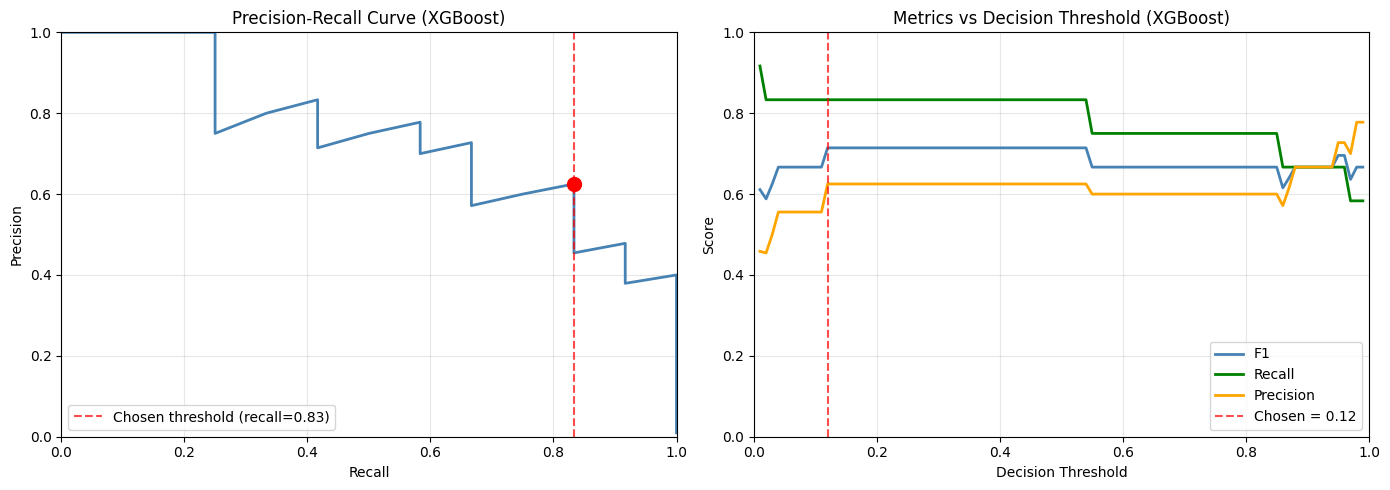

Chart saved: outputs/threshold_tuning.png

complete
   Chosen threshold: 0.12
   Saved: outputs/threshold_tuning.png
   Saved: data/processed/chosen_threshold.csv
Loading data
   Training samples with ESI: 4028
   Test samples with ESI:     988
   ESI range in test set:     0.0000 to 0.8710
   Mean ESI in test set:      0.2592

Training Random Forest Regressor...

Random Forest Regressor:
   RMSE: 0.0233  
   MAE:  0.0103
   R^2:   0.9689

Training XGBoost Regressor...

 XGBoost Regressor:
   RMSE: 0.0236
   MAE:  0.0102
   R^2:   0.9681

Best regressor: Random Forest
   RMSE = 0.0233 0.023 
   MAE  = 0.0102
   R^2   = 0.9689

Top 10 most Earth-like planets (by predicted ESI):
             pl_name  esi_actual  esi_predicted  esi_error
        Kepler-343 b    0.859232       0.831384   0.027847
        Kepler-525 b    0.825212       0.811382   0.013831
KMT-2016-BLG-2364L b    0.870982       0.805357   0.065625
        Kepler-757 b    0.837388       0.801202   0.036185
          TOI-4994 

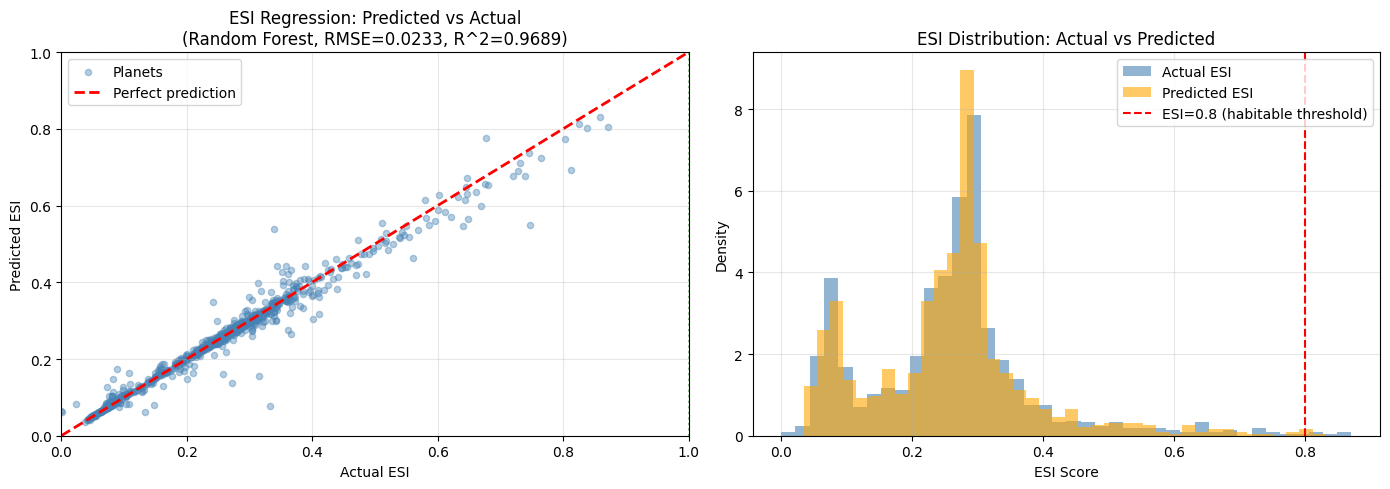


Chart saved: outputs/esi_regression.png

complete
   Best regressor: Random Forest
   RMSE=0.0233  MAE=0.0102  R^2=0.9689
   Saved: models/esi_regressor.pkl
   Saved: outputs/esi_regression.png
Loading final model and test data...
   Chosen threshold: 0.12
   Test set: 1260 planets (12 habitable)

  FINAL MODEL: XGBoost (threshold=0.12)
  Accuracy:          0.9937
  F1 Score:          0.7143  
  Recall:            0.8333 
  Precision:         0.6250
  ROC-AUC:           0.9966
  Avg Precision:     0.7493

CONFUSION MATRIX:
                    Predicted
                  Not Hab  Habitable
  Actual Not Hab:   1242         6
  Actual Habitable:    2        10

 Full Classification Report:
               precision    recall  f1-score   support

Not Habitable       1.00      1.00      1.00      1248
    Habitable       0.62      0.83      0.71        12

     accuracy                           0.99      1260
    macro avg       0.81      0.91      0.86      1260
 weighted avg       0.99  

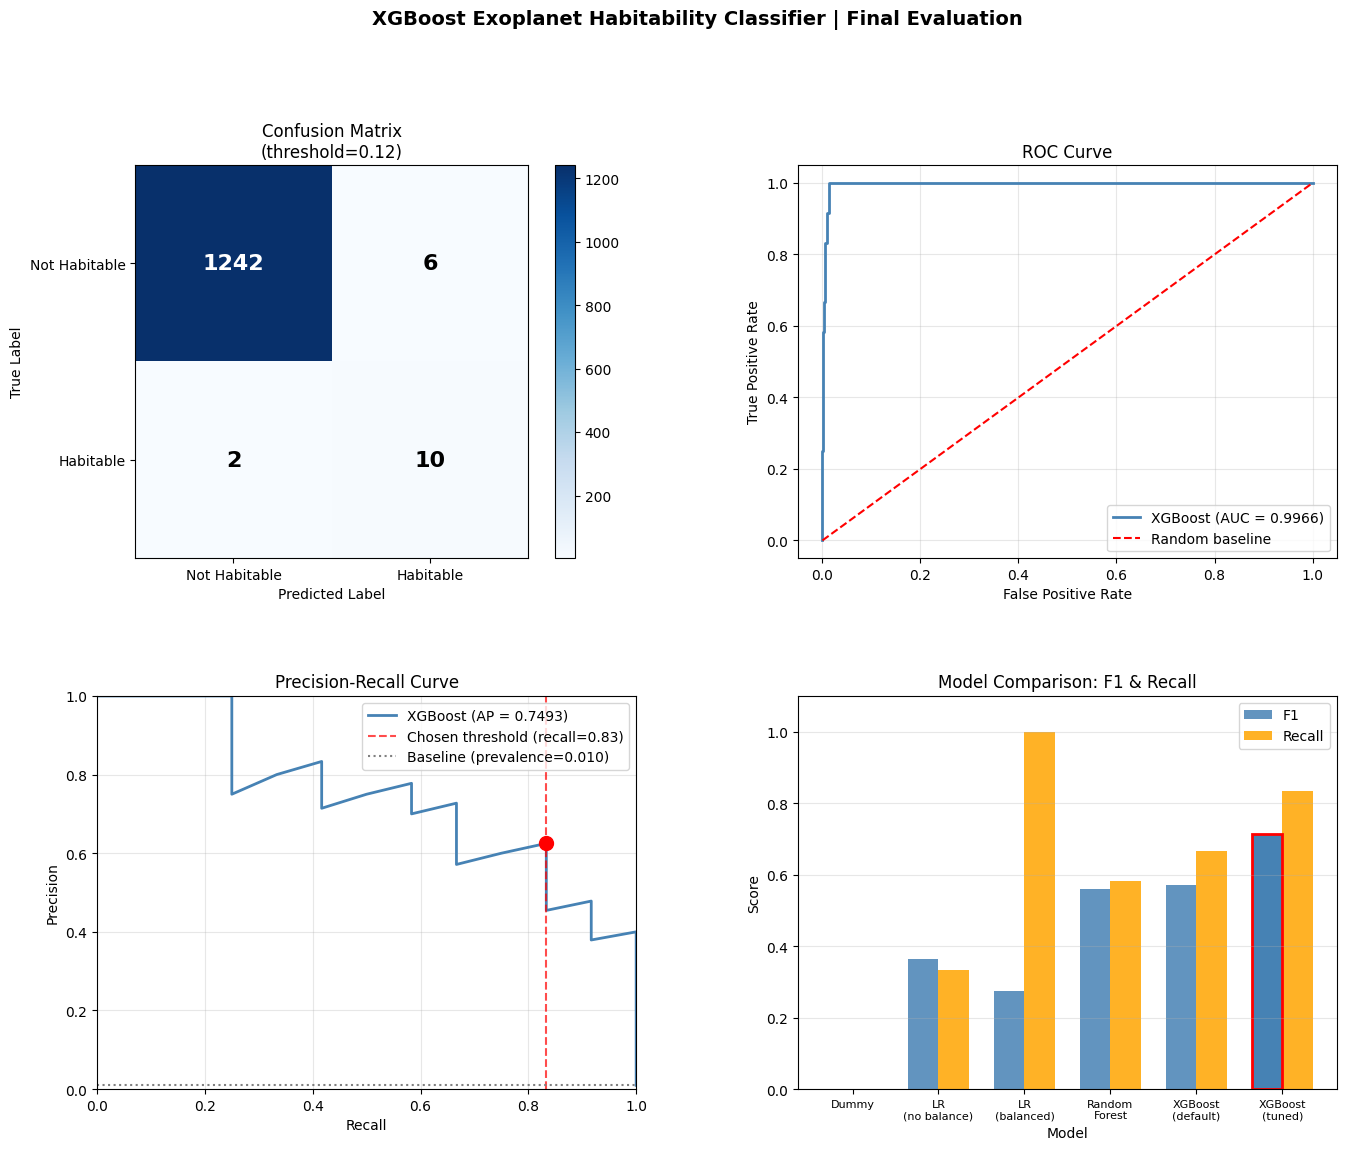

Chart saved: outputs/final_evaluation.png

complete
   Final model: XGBoost at threshold=0.12
   F1=0.7143  Recall=0.8333  AUC=0.9966
   Saved: outputs/final_evaluation.png
   Saved: data/processed/final_scores.csv
Loading model and data...
   Test set: 1260 planets
   Threshold: 0.12

 Computing SHAP values ..
   SHAP values shape: (1260, 16)

GLOBAL FEATURE IMPORTANCE :
Rank   Feature                    Mean |SHAP|
---------------------------------------------
1      temp_delta_earth              3.509044
2      pl_insol                      2.036715
3      pl_rade                       1.726261
4      st_teff                       1.022851
5      pl_orbper                     0.689959
6      pl_eqt                        0.539778
7      density_proxy                 0.528676
8      pl_orbeccen                   0.474999
9      in_habitable_zone             0.441479
10     hz_flux_ratio                 0.412530
11     st_met                        0.302560
12     pl_bmasse           

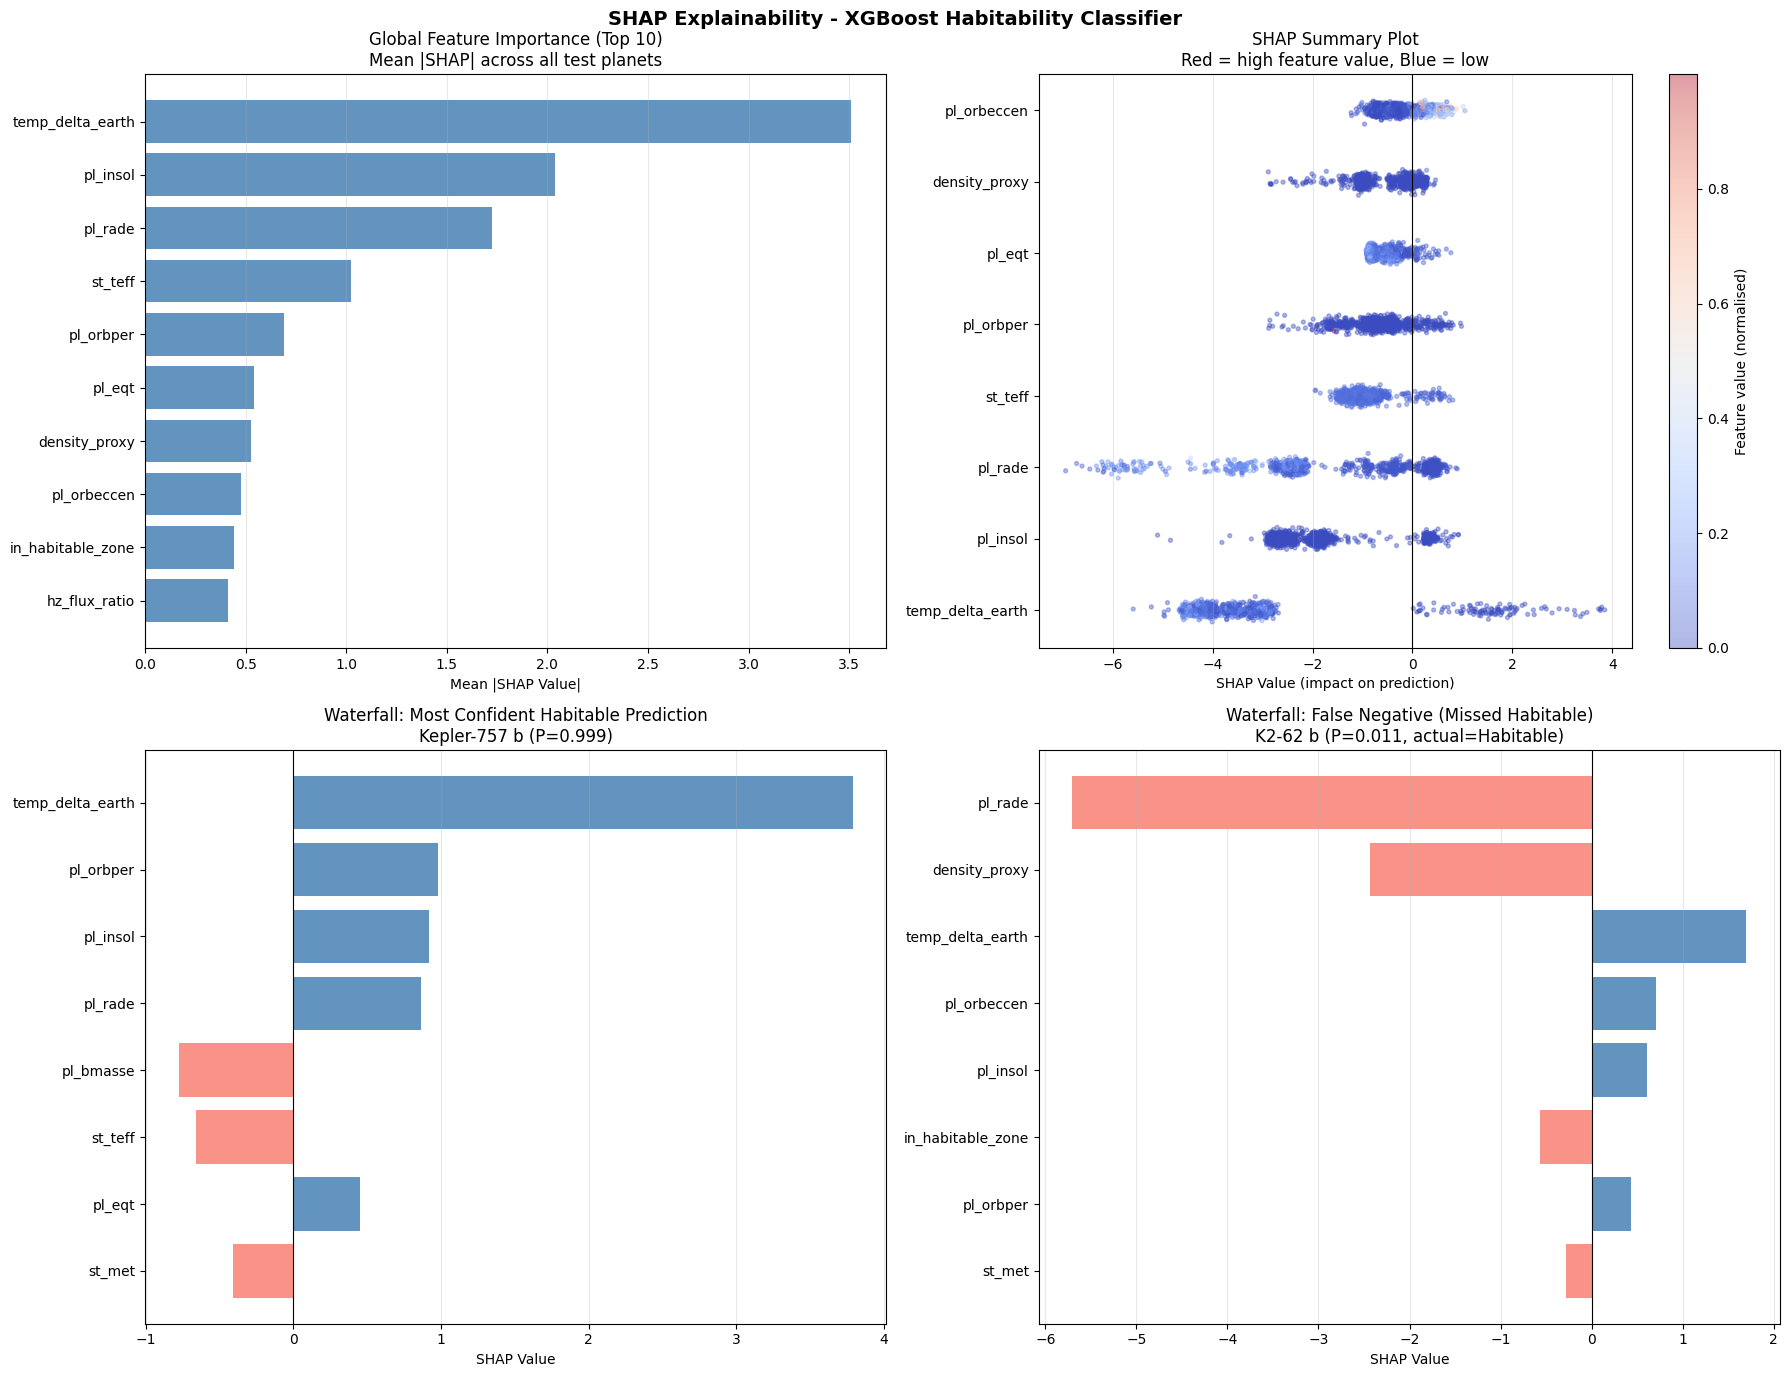

Chart saved: outputs/shap_analysis.png
complete!
   Saved: outputs/shap_analysis.png
   Saved: data/processed/shap_values.csv
   Saved: models/shap_explainer.pkl
Packaging model files for download...
Zip created. Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloads folder for streamlit_app_files.zip


In [1]:

!pip install pandas numpy requests scikit-learn xgboost shap matplotlib seaborn streamlit astroquery



import os
import re
import random
import requests
import zipfile
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
from google.colab import files

# Scikit-Learn tools
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)

from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)





os.makedirs("data/raw",       exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models",         exist_ok=True)
os.makedirs("outputs",        exist_ok=True)

print("complete | folders created, random seed fixed at", SEED)
print("Folder structure:")
for folder in ["data/raw", "data/processed", "models", "outputs"]:
    print(f"   {folder}/")









print("Querying NASA Exoplanet Archive)")

COLUMNS = ",".join([
    "pl_name",
    "pl_orbper",
    "pl_insol",
    "pl_eqt",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "discoverymethod",
    "st_teff",
    "st_met",
    "disc_year",
])


TAP_URL = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=SELECT+{cols}+FROM+pscomppars"
    "&format=csv"
).format(cols=COLUMNS)

response = requests.get(TAP_URL, timeout=120)
response.raise_for_status()


raw_nasa_path = "data/raw/nasa_pscomppars_raw.csv"
with open(raw_nasa_path, "w", encoding="utf-8") as f:
    f.write(response.text)

nasa_df = pd.read_csv(raw_nasa_path)
print(f"NASA data saved: {len(nasa_df)} planets, {nasa_df.shape[1]} columns")
print(f"   File: {raw_nasa_path}")


print("\nMissing value rates (NASA data):")
for col in ["pl_bmasse", "pl_insol", "pl_eqt", "pl_rade", "pl_orbper"]:
    pct = nasa_df[col].isna().mean() * 100
    print(f"   {col:15s}: {pct:.1f}% missing")




print("\nDownloading Habitable Worlds Catalog (HWC)...")

HWC_URL = "http://www.hpcf.upr.edu/~abel/phl/hec2/database/phl_exoplanet_catalog.csv"

try:
    hwc_response = requests.get(HWC_URL, timeout=60)
    hwc_response.raise_for_status()
    raw_hwc_path = "data/raw/hwc_raw.csv"
    with open(raw_hwc_path, "wb") as f:
        f.write(hwc_response.content)
    hwc_df = pd.read_csv(raw_hwc_path, low_memory=False)
    print(f"HWC data saved: {len(hwc_df)} planets, {hwc_df.shape[1]} columns")
    print(f"   File: {raw_hwc_path}")

except Exception as e:
    print(f"HWC download failed: {e}")
    hwc_df = None

if hwc_df is not None:
    print("\n HWC column names:")
    for col in hwc_df.columns.tolist():
        print(f"   {col}")


    name_candidates = [c for c in hwc_df.columns if "name" in c.lower() or "pl_" in c.lower()]
    if name_candidates:
        print(f"\nLikely name columns: {name_candidates}")
        print(hwc_df[name_candidates].head(5).to_string())

print("\ncomplete | raw data saved to data/raw/")








print("loading raw data...")
nasa_df = pd.read_csv("data/raw/nasa_pscomppars_raw.csv")
hwc_df  = pd.read_csv("data/raw/hwc_raw.csv", low_memory=False)
print(f"   NASA: {len(nasa_df)} rows")
print(f"   HWC:  {len(hwc_df)} rows")


hwc_name_col = "P_NAME"
print(f"\nHWC name column: '{hwc_name_col}'")
print(f"   Sample HWC names: {hwc_df[hwc_name_col].dropna().head(5).tolist()}")
print(f"   Sample NASA names: {nasa_df['pl_name'].dropna().head(5).tolist()}")


def normalise_name(name):
    if pd.isna(name):
        return np.nan
    name = str(name).strip().lower()
    name = re.sub(r'(\d)\s+([a-z])$', r'\1\2', name)
    return name

nasa_df["name_key"] = nasa_df["pl_name"].apply(normalise_name)
hwc_df["name_key"]  = hwc_df[hwc_name_col].apply(normalise_name)
print(f"\nName normalisation complete")
print(f"   NASA sample: {nasa_df['name_key'].head(3).tolist()}")
print(f"   HWC  sample: {hwc_df['name_key'].head(3).tolist()}")


# P_HABITABLE: 0=not habitable,1=conservative, 2=optimistic
# P_ESI: earth similarity index (0.0-1.0)
hwc_slim = hwc_df[["name_key", "P_ESI", "P_HABITABLE"]].copy()
hwc_slim = hwc_slim.rename(columns={"P_ESI": "esi_score", "P_HABITABLE": "hwc_hab_label"})


merged_df = nasa_df.merge(hwc_slim, on="name_key", how="left")

total_nasa = len(nasa_df)
matched    = merged_df["esi_score"].notna().sum()
unmatched  = total_nasa - matched
print(f"\n MERGE REPORT:")
print(f"   NASA planets total:             {total_nasa}")
print(f"   HWC planets total:              {len(hwc_df)}")
print(f"   Successfully matched:           {matched}  ({matched/total_nasa*100:.1f}%)")
print(f"   NASA planets with no HWC match: {unmatched}  ({unmatched/total_nasa*100:.1f}%)")


# 1=habitable (conservative or optimistic), 0=not habitable
merged_df["is_habitable"] = merged_df["hwc_hab_label"].apply(
    lambda x: 1 if (pd.notna(x) and x > 0) else 0
)
habitable_count = merged_df["is_habitable"].sum()
print(f"\nHabitable planets labelled:    {habitable_count} ({habitable_count/total_nasa*100:.2f}%)")
print(f"   Not habitable:                 {total_nasa - habitable_count}")
print(f"\n  Class imbalance ratio: 1 : {(total_nasa - habitable_count)//max(habitable_count,1)}")


#save
merged_path = "data/processed/merged_dataset.csv"
merged_df.to_csv(merged_path, index=False)
print(f"\ncomplete | saved to {merged_path}")
print(f"   Shape: {merged_df.shape[0]} rows × {merged_df.shape[1]} columns")













print("Loading merged dataset...")
df = pd.read_csv("data/processed/merged_dataset.csv")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")


FEATURE_COLS = [
    "pl_orbper",
    "pl_insol",
    "pl_eqt",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "st_teff",
    "st_met",
]

TARGETS = ["is_habitable", "esi_score"]


cols_to_keep = ["pl_name"] + FEATURE_COLS + TARGETS
df_work = df[cols_to_keep].copy()

print(f"\nMISSINGNESS REPORT :")
print(f"{'Column':<15} {'Missing':>8} {'%':>8}")
print("-" * 35)
for col in FEATURE_COLS:
    n_missing = df_work[col].isna().sum()
    pct = n_missing / len(df_work) * 100
    flag = " " if pct > 20 else ""
    print(f"{col:<15} {n_missing:>8} {pct:>7.1f}%{flag}")



if "discoverymethod" in df_work.columns:
    le = LabelEncoder()
    df_work["discoverymethod"] = le.fit_transform(
        df_work["discoverymethod"].fillna("Unknown")
    )


print("\nRunning median imputation...")
median_imputer = SimpleImputer(strategy="median")
X_median = df_work[FEATURE_COLS].copy()
X_median_imputed = pd.DataFrame(
    median_imputer.fit_transform(X_median),
    columns=FEATURE_COLS
)
print("Median imputation complete")


assert X_median_imputed.isna().sum().sum() == 0, "Still missing values after median"
print(f"   Missing values remaining: {X_median_imputed.isna().sum().sum()} ")


print("\n  Running KNN imputation (k=5)")
knn_imputer = KNNImputer(n_neighbors=5)
X_knn = df_work[FEATURE_COLS].copy()
X_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X_knn),
    columns=FEATURE_COLS
)
print(" KNN imputation complete")
assert X_knn_imputed.isna().sum().sum() == 0, "Still missing values after KNN"
print(f"   Missing values remaining: {X_knn_imputed.isna().sum().sum()} ")


print(f"\nIMPUTATION COMPARISON :")
print(f"{'Column':<15} {'Median_mean':>12} {'KNN_mean':>12} {'Median_std':>12} {'KNN_std':>12}")
print("-" * 65)


for col in FEATURE_COLS:
    had_missing = df_work[col].isna().sum() > 0
    if had_missing:
        print(f"{col:<15} "
              f"{X_median_imputed[col].mean():>12.3f} "
              f"{X_knn_imputed[col].mean():>12.3f} "
              f"{X_median_imputed[col].std():>12.3f} "
              f"{X_knn_imputed[col].std():>12.3f}")



df_final = df_work.copy()
df_final[FEATURE_COLS] = X_knn_imputed


df_median = df_work.copy()
df_median[FEATURE_COLS] = X_median_imputed

df_final.to_csv("data/processed/dataset_knn_imputed.csv", index=False)
df_median.to_csv("data/processed/dataset_median_imputed.csv", index=False)

print(f" complete")
print(f"   Saved: data/processed/dataset_knn_imputed.csv ")
print(f"   Saved: data/processed/dataset_median_imputed.csv ")





















print("Loading KNN-imputed dataset...")
df = pd.read_csv("data/processed/dataset_knn_imputed.csv")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")


HZ_MIN = 0.25
HZ_MAX = 1.5

df["hz_flux_ratio"] = df["pl_insol"] / 1.0  # normalise to Earth flux = 1.0
df["in_habitable_zone"] = (
    (df["pl_insol"] >= HZ_MIN) & (df["pl_insol"] <= HZ_MAX)
).astype(int)

print(f"\nFeature 1: Habitable zone flux ratio")
print(f"   Planets inside habitable zone (flux): {df['in_habitable_zone'].sum()}")
print(f"   Mean flux ratio: {df['hz_flux_ratio'].mean():.3f}")



df["density_proxy"] = df["pl_bmasse"] / (df["pl_rade"] ** 3)

print(f"\nFeature 2: Bulk density proxy (mass/radius³)")
print(f"   Mean density proxy: {df['density_proxy'].mean():.4f}")
print(f"   Min: {df['density_proxy'].min():.4f}  Max: {df['density_proxy'].max():.4f}")


EARTH_EQ_TEMP = 255.0

df["temp_delta_earth"] = abs(df["pl_eqt"] - EARTH_EQ_TEMP)

print(f"\nFeature 3: Temperature delta from Earth (255K baseline)")
print(f"   Mean temp delta: {df['temp_delta_earth'].mean():.1f} K")
print(f"   Planets within 50K of Earth: {(df['temp_delta_earth'] <= 50).sum()}")
print(f"   Planets within 100K of Earth: {(df['temp_delta_earth'] <= 100).sum()}")


def classify_star(teff):
    if pd.isna(teff):
        return "Unknown"
    elif teff < 3900:
        return "M"
    elif teff < 5300:
        return "K"
    elif teff < 6000:
        return "G"
    elif teff < 7300:
        return "F"
    else:
        return "Hot"

df["stellar_class"] = df["st_teff"].apply(classify_star)


stellar_dummies = pd.get_dummies(df["stellar_class"], prefix="star", drop_first=True)
df = pd.concat([df, stellar_dummies], axis=1)

print(f"\nFeature 4: Stellar class encoding")
print(f"   Star class distribution:")
print(df["stellar_class"].value_counts().to_string())


# ESI = weighted geometric mean of how similar each param is to Earth
# Formula: ESI = product of (1 - |x - x_earth| / (x + x_earth))^w
# where w = weight for each parameter


EARTH_RADIUS  = 1.0
EARTH_MASS    = 1.0
EARTH_FLUX    = 1.0
EARTH_TEMP    = 255.0

W_RADIUS = 0.57
W_MASS   = 1.07
W_FLUX   = 0.70
W_TEMP   = 5.58
W_TOTAL  = W_RADIUS + W_MASS + W_FLUX + W_TEMP

def compute_esi(row):
    try:
        esi_r = (1 - abs(row["pl_rade"]   - EARTH_RADIUS) / (row["pl_rade"]   + EARTH_RADIUS)) ** (W_RADIUS / W_TOTAL)
        esi_m = (1 - abs(row["pl_bmasse"] - EARTH_MASS)   / (row["pl_bmasse"] + EARTH_MASS))   ** (W_MASS   / W_TOTAL)
        esi_f = (1 - abs(row["pl_insol"]  - EARTH_FLUX)   / (row["pl_insol"]  + EARTH_FLUX))   ** (W_FLUX   / W_TOTAL)
        esi_t = (1 - abs(row["pl_eqt"]    - EARTH_TEMP)   / (row["pl_eqt"]    + EARTH_TEMP))   ** (W_TEMP   / W_TOTAL)
        return round(esi_r * esi_m * esi_f * esi_t, 4)
    except:
        return np.nan

df["esi_computed"] = df.apply(compute_esi, axis=1)


both_valid = df[df["esi_score"].notna() & df["esi_computed"].notna()]
correlation = both_valid["esi_score"].corr(both_valid["esi_computed"])
print(f"\n ESI sanity check")
print(f"   Correlation between computed ESI and HWC ESI: {correlation:.4f}")
print(f"   (1.0 = perfect match, >0.9 = good sanity check )")


NEW_FEATURES = [
    "hz_flux_ratio",
    "in_habitable_zone",
    "density_proxy",
    "temp_delta_earth",
    "stellar_class",
    "esi_computed",
] + list(stellar_dummies.columns)

print(f"\nALL ENGINEERED FEATURES ADDED:")
for f in NEW_FEATURES:
    if f in df.columns:
        print(f"   + {f}")


df.to_csv("data/processed/dataset_features.csv", index=False)
print(f"\ncomplete")
print(f"   Saved: data/processed/dataset_features.csv")
print(f"   Final shape: {df.shape[0]} rows × {df.shape[1]} columns")















print("Loading feature-engineered dataset...")
df = pd.read_csv("data/processed/dataset_features.csv")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")



ML_FEATURES = [
    # Original physical features
    "pl_orbper",
    "pl_insol",
    "pl_eqt",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "st_teff",
    "st_met",
    # Engineered features
    "hz_flux_ratio",
    "in_habitable_zone",
    "density_proxy",
    "temp_delta_earth",
    "star_G",
    "star_Hot",
    "star_K",
    "star_M",
]

Y1 = "is_habitable"   # classification tgt
Y2 = "esi_score"      # regression tgt

X = df[ML_FEATURES]
y1 = df[Y1]
y2 = df[Y2]

print(f"\nFeature matrix shape: {X.shape}")
print(f"   Classification target (Y1): {y1.sum()} habitable, {(y1==0).sum()} not habitable")
print(f"   Regression target (Y2): {y2.notna().sum()} planets have ESI scores")


X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2,
    test_size=0.2,
    random_state=SEED,
    stratify=y1
)

print(f"\nStratified train/test split complete (80/20)")
print(f"\nSPLIT REPORT:")
print(f"   Training set:  {len(X_train)} planets")
print(f"   Test set:      {len(X_test)} planets")
print(f"\n   Habitable in train: {y1_train.sum()} ({y1_train.mean()*100:.2f}%)")
print(f"   Habitable in test:  {y1_test.sum()}  ({y1_test.mean()*100:.2f}%)")
print(f"\n   Proportions match | stratification worked correctly")


from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"\nCross-validation plan:")
print(f"   Strategy: StratifiedKFold with 5 folds")
print(f"   Applied to: training set only ({len(X_train)} planets)")
print(f"   Habitable planets per fold (approx): {y1_train.sum() // 5}")
print(f"   Test set kept completely untouched until final evaluation")


X_train.to_csv("data/processed/X_train.csv", index=False)
X_test.to_csv("data/processed/X_test.csv",  index=False)
y1_train.to_csv("data/processed/y1_train.csv", index=False)
y1_test.to_csv("data/processed/y1_test.csv",  index=False)
y2_train.to_csv("data/processed/y2_train.csv", index=False)
y2_test.to_csv("data/processed/y2_test.csv",  index=False)

print(f"\ncomplete | all splits saved to data/processed/")
print(f"   X_train.csv, X_test.csv")
print(f"   y1_train.csv, y1_test.csv  (classification)")
print(f"   y2_train.csv, y2_test.csv  (regression)")









print("Loading train/test splits...")
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")
y1_train = pd.read_csv("data/processed/y1_train.csv").squeeze()
y1_test  = pd.read_csv("data/processed/y1_test.csv").squeeze()

print(f"   Train: {len(X_train)} planets ({y1_train.sum()} habitable)")
print(f"   Test:  {len(X_test)} planets ({y1_test.sum()} habitable)")


print("\n Running dummy classifier")
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y1_train)
y_dummy_pred = dummy.predict(X_test)

dummy_accuracy  = accuracy_score(y1_test, y_dummy_pred)
dummy_f1        = f1_score(y1_test, y_dummy_pred, zero_division=0)
dummy_recall    = recall_score(y1_test, y_dummy_pred, zero_division=0)
dummy_precision = precision_score(y1_test, y_dummy_pred, zero_division=0)

print(f"\nDUMMY CLASSIFIER RESULTS :")
print(f"{'Metric':<20} {'Score':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {dummy_accuracy:>10.4f}")
print(f"{'F1 Score':<20} {dummy_f1:>10.4f} ")
print(f"{'Recall':<20} {dummy_recall:>10.4f}  ")
print(f"{'Precision':<20} {dummy_precision:>10.4f}")

print(f"\nConfusion Matrix (Dummy):")
cm = confusion_matrix(y1_test, y_dummy_pred)
print(f"   Predicted:     Not Hab   Habitable")
print(f"   Actual Not Hab:  {cm[0][0]:>5}      {cm[0][1]:>5}")
print(f"   Actual Habitable:{cm[1][0]:>5}      {cm[1][1]:>5}")




print("Running random baseline")
dummy_random = DummyClassifier(strategy="stratified", random_state=SEED)
dummy_random.fit(X_train, y1_train)
y_random_pred = dummy_random.predict(X_test)

random_accuracy = accuracy_score(y1_test, y_random_pred)
random_f1       = f1_score(y1_test, y_random_pred, zero_division=0)
random_recall   = recall_score(y1_test, y_random_pred, zero_division=0)

print(f"\nRANDOM BASELINE RESULTS:")
print(f"{'Metric':<20} {'Score':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {random_accuracy:>10.4f}")
print(f"{'F1 Score':<20} {random_f1:>10.4f}")
print(f"{'Recall':<20} {random_recall:>10.4f}")



baseline_scores = pd.DataFrame([{
    "model": "Dummy (majority class)",
    "accuracy": dummy_accuracy,
    "f1": dummy_f1,
    "recall": dummy_recall,
    "precision": dummy_precision,
}])
baseline_scores.to_csv("data/processed/model_scores.csv", index=False)

print("complete | baseline scores saved to data/processed/model_scores.csv")









print("Loading train/test splits...")
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")
y1_train = pd.read_csv("data/processed/y1_train.csv").squeeze()
y1_test  = pd.read_csv("data/processed/y1_test.csv").squeeze()

print(f"   Train: {len(X_train)} planets ({y1_train.sum()} habitable)")
print(f"   Test:  {len(X_test)} planets ({y1_test.sum()} habitable)")


print("\n Running dummy classifier")
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y1_train)
y_dummy_pred = dummy.predict(X_test)

dummy_accuracy  = accuracy_score(y1_test, y_dummy_pred)
dummy_f1        = f1_score(y1_test, y_dummy_pred, zero_division=0)
dummy_recall    = recall_score(y1_test, y_dummy_pred, zero_division=0)
dummy_precision = precision_score(y1_test, y_dummy_pred, zero_division=0)

print(f"\nDUMMY CLASSIFIER RESULTS :")
print(f"{'Metric':<20} {'Score':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {dummy_accuracy:>10.4f}")
print(f"{'F1 Score':<20} {dummy_f1:>10.4f} ")
print(f"{'Recall':<20} {dummy_recall:>10.4f}  ")
print(f"{'Precision':<20} {dummy_precision:>10.4f}")

print(f"\nConfusion Matrix (Dummy):")
cm = confusion_matrix(y1_test, y_dummy_pred)
print(f"   Predicted:     Not Hab   Habitable")
print(f"   Actual Not Hab:  {cm[0][0]:>5}      {cm[0][1]:>5}")
print(f"   Actual Habitable:{cm[1][0]:>5}      {cm[1][1]:>5}")




print("Running random baseline")
dummy_random = DummyClassifier(strategy="stratified", random_state=SEED)
dummy_random.fit(X_train, y1_train)
y_random_pred = dummy_random.predict(X_test)

random_accuracy = accuracy_score(y1_test, y_random_pred)
random_f1       = f1_score(y1_test, y_random_pred, zero_division=0)
random_recall   = recall_score(y1_test, y_random_pred, zero_division=0)

print(f"\nRANDOM BASELINE RESULTS:")
print(f"{'Metric':<20} {'Score':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {random_accuracy:>10.4f}")
print(f"{'F1 Score':<20} {random_f1:>10.4f}")
print(f"{'Recall':<20} {random_recall:>10.4f}")


print(f"""
BASELINE BAR SET:


   Dummy accuracy:  {dummy_accuracy:.4f}
   Dummy F1:        {dummy_f1:.4f}
   Dummy recall:    {dummy_recall:.4f}

   Target for best model:
   F1 > 0.5, Recall > 0.6
""")


baseline_scores = pd.DataFrame([{
    "model": "Dummy (majority class)",
    "accuracy": dummy_accuracy,
    "f1": dummy_f1,
    "recall": dummy_recall,
    "precision": dummy_precision,
}])
baseline_scores.to_csv("data/processed/model_scores.csv", index=False)

print("complete | baseline scores saved to data/processed/model_scores.csv")











print("Loading splits...")
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")
y1_train = pd.read_csv("data/processed/y1_train.csv").squeeze()
y1_test  = pd.read_csv("data/processed/y1_test.csv").squeeze()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores = pd.read_csv("data/processed/model_scores.csv")

def evaluate(name, model, X_tr, y_tr, X_te, y_te, needs_scaling=False):
    """Train, cross-validate, test and report a model."""
    if needs_scaling:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te  = scaler.transform(X_te)


    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=skf,
                             scoring="f1", n_jobs=-1)
    cv_recall = cross_val_score(model, X_tr, y_tr, cv=skf,
                                 scoring="recall", n_jobs=-1)


    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    cm   = confusion_matrix(y_te, y_pred)

    print(f"\n--- {name} ---")
    print(f"  CV F1  (5-fold): {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}")
    print(f"  CV Recall:       {cv_recall.mean():.4f}  +/- {cv_recall.std():.4f}")
    print(f"  --- Test set ---")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"  Confusion matrix:")
    print(f"    Predicted:      Not Hab  Habitable")
    print(f"    Actual Not Hab:  {cm[0][0]:>5}     {cm[0][1]:>5}")
    print(f"    Actual Habitable:{cm[1][0]:>5}     {cm[1][1]:>5}")

    return {
        "model": name,
        "accuracy": round(acc, 4),
        "f1": round(f1, 4),
        "recall": round(rec, 4),
        "precision": round(prec, 4),
        "roc_auc": round(auc, 4),
        "cv_f1_mean": round(cv_f1.mean(), 4),
        "cv_f1_std": round(cv_f1.std(), 4),
    }, model


# MODEL 1: Logistic Regression (no imbalance handling)
print("\nMODEL 1: Logistic Regression | no imbalance handling")

lr_basic = LogisticRegression(max_iter=1000, random_state=SEED)
row1, _ = evaluate(
    "Logistic Regression (no balancing)",
    lr_basic, X_train, y1_train, X_test, y1_test,
    needs_scaling=True
)
scores = pd.concat([scores, pd.DataFrame([row1])], ignore_index=True)


# MODEL 2: Logistic Regression + class_weight='balanced'
print("\n MODEL 2: Logistic Regression + class_weight='balanced'")

lr_balanced = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=SEED
)
row2, _ = evaluate(
    "Logistic Regression (balanced weights)",
    lr_balanced, X_train, y1_train, X_test, y1_test,
    needs_scaling=True
)
recall_improvement = row2['recall'] - row1['recall']
scores = pd.concat([scores, pd.DataFrame([row2])], ignore_index=True)


# MODEL 3: Random Forest
print("\nMODEL 3: Random Forest + class_weight='balanced'")

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
row3, rf_fitted = evaluate(
    "Random Forest (balanced, 300 trees)",
    rf, X_train, y1_train, X_test, y1_test,
    needs_scaling=False
)

scores = pd.concat([scores, pd.DataFrame([row3])], ignore_index=True)


# MODEL 4: XGBoost
print("\nMODEL 4: XGBoost with scale_pos_weight")



scale = int((y1_train == 0).sum() / (y1_train == 1).sum())
print(f"   scale_pos_weight = {scale} (negative/positive ratio)")

xgb = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1
)
row4, xgb_fitted = evaluate(
    "XGBoost (scale_pos_weight)",
    xgb, X_train, y1_train, X_test, y1_test,
    needs_scaling=False
)

scores = pd.concat([scores, pd.DataFrame([row4])], ignore_index=True)


# final comparison table
print(f"\n{'='*55}")
print(" MODEL COMPARISON TABLE")
print(f"{'='*55}")
print(f"{'Model':<40} {'F1':>6} {'Recall':>8} {'AUC':>7}")
print("-" * 63)
for _, row in scores.iterrows():
    print(f"{row['model']:<40} {row['f1']:>6.4f} {row['recall']:>8.4f} {row['roc_auc']:>7.4f}")


scores.to_csv("data/processed/model_scores.csv", index=False)

# Save best models
import joblib
joblib.dump(rf_fitted,  "models/random_forest.pkl")
joblib.dump(xgb_fitted, "models/xgboost.pkl")


scaler = StandardScaler()
scaler.fit(X_train)
joblib.dump(scaler, "models/scaler.pkl")

print(f"\ncomplete")
print(f"   Models saved: models/random_forest.pkl, models/xgboost.pkl")
print(f"   Scores saved: data/processed/model_scores.csv")






print("Loading data and best model...")
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")
y1_train = pd.read_csv("data/processed/y1_train.csv").squeeze()
y1_test  = pd.read_csv("data/processed/y1_test.csv").squeeze()
xgb = joblib.load("models/xgboost.pkl")

y_prob = xgb.predict_proba(X_test)[:, 1]

print(f"   Probability range: {y_prob.min():.4f} to {y_prob.max():.4f}")
print(f"   Planets with prob > 0.5: {(y_prob > 0.5).sum()}")
print(f"   Planets with prob > 0.1: {(y_prob > 0.1).sum()}")


thresholds = np.arange(0.01, 1.0, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1   = f1_score(y1_test, y_pred_t, zero_division=0)
    rec  = recall_score(y1_test, y_pred_t, zero_division=0)
    prec = precision_score(y1_test, y_pred_t, zero_division=0)
    tp = ((y_pred_t == 1) & (y1_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y1_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y1_test == 1)).sum()
    results.append({
        "threshold": round(t, 2),
        "f1": round(f1, 4),
        "recall": round(rec, 4),
        "precision": round(prec, 4),
        "tp": tp, "fp": fp, "fn": fn
    })

results_df = pd.DataFrame(results)


best_f1_row = results_df.loc[results_df["f1"].idxmax()]


high_recall = results_df[results_df["recall"] >= 0.75]
best_recall_row = high_recall.loc[high_recall["precision"].idxmax()] \
    if len(high_recall) > 0 else best_f1_row

print(f"\nTHRESHOLD ANALYSIS:")
print(f"\n   Default threshold (0.50):")
default = results_df[results_df["threshold"] == 0.50].iloc[0]
print(f"   F1={default['f1']:.4f}  Recall={default['recall']:.4f}  "
      f"Precision={default['precision']:.4f}  "
      f"TP={default['tp']}  FP={default['fp']}  FN={default['fn']}")

print(f"\n   Best F1 threshold ({best_f1_row['threshold']}):")
print(f"   F1={best_f1_row['f1']:.4f}  Recall={best_f1_row['recall']:.4f}  "
      f"Precision={best_f1_row['precision']:.4f}  "
      f"TP={int(best_f1_row['tp'])}  FP={int(best_f1_row['fp'])}  "
      f"FN={int(best_f1_row['fn'])}")

print(f"\n   Best recall threshold ({best_recall_row['threshold']}):")
print(f"   F1={best_recall_row['f1']:.4f}  Recall={best_recall_row['recall']:.4f}  "
      f"Precision={best_recall_row['precision']:.4f}  "
      f"TP={int(best_recall_row['tp'])}  FP={int(best_recall_row['fp'])}  "
      f"FN={int(best_recall_row['fn'])}")


CHOSEN_THRESHOLD = float(best_recall_row["threshold"])
y_final = (y_prob >= CHOSEN_THRESHOLD).astype(int)

f1_final   = f1_score(y1_test, y_final, zero_division=0)
rec_final  = recall_score(y1_test, y_final, zero_division=0)
prec_final = precision_score(y1_test, y_final, zero_division=0)
cm_final   = confusion_matrix(y1_test, y_final)

print(f"""
CHOSEN THRESHOLD: {CHOSEN_THRESHOLD}


   Final results at threshold {CHOSEN_THRESHOLD}:
   F1        = {f1_final:.4f}
   Recall    = {rec_final:.4f}  ({int(rec_final*12)}/12 habitable planets found)
   Precision = {prec_final:.4f}

   Confusion matrix:
     Predicted:      Not Hab  Habitable
     Actual Not Hab:  {cm_final[0][0]:>5}     {cm_final[0][1]:>5}
     Actual Habitable:{cm_final[1][0]:>5}     {cm_final[1][1]:>5}

   {cm_final[1][0]} false negatives = {cm_final[1][0]} potentially missed habitable worlds
   {cm_final[0][1]} false positives = {cm_final[0][1]} planets needing unnecessary follow-up
""")


precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
    y1_test, y_prob
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Precision-Recall curve
axes[0].plot(recall_vals, precision_vals, color="steelblue", lw=2)
axes[0].axvline(rec_final, color="red", linestyle="--", alpha=0.7,
                label=f"Chosen threshold (recall={rec_final:.2f})")
axes[0].scatter([rec_final], [prec_final], color="red", s=100, zorder=5)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (XGBoost)")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# F1, Recall, Precision vs Threshold
axes[1].plot(results_df["threshold"], results_df["f1"],
             label="F1", color="steelblue", lw=2)
axes[1].plot(results_df["threshold"], results_df["recall"],
             label="Recall", color="green", lw=2)
axes[1].plot(results_df["threshold"], results_df["precision"],
             label="Precision", color="orange", lw=2)
axes[1].axvline(CHOSEN_THRESHOLD, color="red", linestyle="--",
                alpha=0.7, label=f"Chosen = {CHOSEN_THRESHOLD}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Metrics vs Decision Threshold (XGBoost)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig("outputs/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: outputs/threshold_tuning.png")


threshold_info = {"chosen_threshold": CHOSEN_THRESHOLD,
                  "f1": f1_final, "recall": rec_final,
                  "precision": prec_final}
pd.DataFrame([threshold_info]).to_csv(
    "data/processed/chosen_threshold.csv", index=False
)


scores = pd.read_csv("data/processed/model_scores.csv")
tuned_row = pd.DataFrame([{
    "model": f"XGBoost (threshold={CHOSEN_THRESHOLD})",
    "accuracy": None,
    "f1": round(f1_final, 4),
    "recall": round(rec_final, 4),
    "precision": round(prec_final, 4),
    "roc_auc": round(roc_auc_score(y1_test, y_prob), 4),
    "cv_f1_mean": None,
    "cv_f1_std": None,
}])
scores = pd.concat([scores, tuned_row], ignore_index=True)
scores.to_csv("data/processed/model_scores.csv", index=False)

print(f"\ncomplete")
print(f"   Chosen threshold: {CHOSEN_THRESHOLD}")
print(f"   Saved: outputs/threshold_tuning.png")
print(f"   Saved: data/processed/chosen_threshold.csv")











print("Loading data")
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")
y2_train = pd.read_csv("data/processed/y2_train.csv").squeeze()
y2_test  = pd.read_csv("data/processed/y2_test.csv").squeeze()


train_mask = y2_train.notna()
test_mask  = y2_test.notna()

X_train_esi = X_train[train_mask]
y_train_esi = y2_train[train_mask]
X_test_esi  = X_test[test_mask]
y_test_esi  = y2_test[test_mask]

print(f"   Training samples with ESI: {len(X_train_esi)}")
print(f"   Test samples with ESI:     {len(X_test_esi)}")
print(f"   ESI range in test set:     {y_test_esi.min():.4f} to {y_test_esi.max():.4f}")
print(f"   Mean ESI in test set:      {y_test_esi.mean():.4f}")

#MODEL 1: Random Forest Regressor
print("\nTraining Random Forest Regressor...")
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf_reg.fit(X_train_esi, y_train_esi)
y_pred_rf = rf_reg.predict(X_test_esi)

rmse_rf = np.sqrt(mean_squared_error(y_test_esi, y_pred_rf))
mae_rf  = mean_absolute_error(y_test_esi, y_pred_rf)
r2_rf   = r2_score(y_test_esi, y_pred_rf)

print(f"\nRandom Forest Regressor:")
print(f"   RMSE: {rmse_rf:.4f}  ")
print(f"   MAE:  {mae_rf:.4f}")
print(f"   R^2:   {r2_rf:.4f}")

# MODEL 2: XGBoost Regressor
print("\nTraining XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)
xgb_reg.fit(X_train_esi, y_train_esi)
y_pred_xgb = xgb_reg.predict(X_test_esi)

rmse_xgb = np.sqrt(mean_squared_error(y_test_esi, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test_esi, y_pred_xgb)
r2_xgb   = r2_score(y_test_esi, y_pred_xgb)

print(f"\n XGBoost Regressor:")
print(f"   RMSE: {rmse_xgb:.4f}")
print(f"   MAE:  {mae_xgb:.4f}")
print(f"   R^2:   {r2_xgb:.4f}")

# Choose best regressor
best_reg    = xgb_reg if rmse_xgb <= rmse_rf else rf_reg
best_name   = "XGBoost" if rmse_xgb <= rmse_rf else "Random Forest"
best_pred   = y_pred_xgb if rmse_xgb <= rmse_rf else y_pred_rf
best_rmse   = min(rmse_xgb, rmse_rf)
best_mae    = min(mae_xgb, mae_rf)
best_r2     = r2_xgb if rmse_xgb <= rmse_rf else r2_rf

print(f"\nBest regressor: {best_name}")
print(f"   RMSE = {best_rmse:.4f} "
      f"{best_rmse:.3f} ")
print(f"   MAE  = {best_mae:.4f}")
print(f"   R^2   = {best_r2:.4f}")


results_df = X_test_esi.copy()
results_df["pl_name"]   = pd.read_csv("data/processed/dataset_features.csv")\
    .loc[X_test_esi.index, "pl_name"].values
results_df["esi_actual"]    = y_test_esi.values
results_df["esi_predicted"] = best_pred
results_df["esi_error"]     = abs(results_df["esi_actual"] - results_df["esi_predicted"])


top_earthlike = results_df.nlargest(10, "esi_predicted")[
    ["pl_name", "esi_actual", "esi_predicted", "esi_error"]
]
print(f"\nTop 10 most Earth-like planets (by predicted ESI):")
print(top_earthlike.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Predicted vs Actual ESI scatter
axes[0].scatter(y_test_esi, best_pred, alpha=0.4,
                color="steelblue", s=20, label="Planets")
axes[0].plot([0, 1], [0, 1], "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual ESI")
axes[0].set_ylabel("Predicted ESI")
axes[0].set_title(f"ESI Regression: Predicted vs Actual\n"
                  f"({best_name}, RMSE={best_rmse:.4f}, R^2={best_r2:.4f})")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# add earth reference line
axes[0].axvline(1.0, color="green", alpha=0.5, linestyle=":", label="Earth ESI=1.0")
axes[0].axhline(1.0, color="green", alpha=0.5, linestyle=":")

#ESI distribution - actual vs predicted
axes[1].hist(y_test_esi, bins=40, alpha=0.6,
             color="steelblue", label="Actual ESI", density=True)
axes[1].hist(best_pred, bins=40, alpha=0.6,
             color="orange", label="Predicted ESI", density=True)
axes[1].axvline(0.8, color="red", linestyle="--",
                label="ESI=0.8 (habitable threshold)")
axes[1].set_xlabel("ESI Score")
axes[1].set_ylabel("Density")
axes[1].set_title("ESI Distribution: Actual vs Predicted")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/esi_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: outputs/esi_regression.png")


joblib.dump(best_reg, "models/esi_regressor.pkl")
joblib.dump(best_reg, f"models/esi_{best_name.lower().replace(' ','_')}.pkl")

print(f"\ncomplete")
print(f"   Best regressor: {best_name}")
print(f"   RMSE={best_rmse:.4f}  MAE={best_mae:.4f}  R^2={best_r2:.4f}")
print(f"   Saved: models/esi_regressor.pkl")
print(f"   Saved: outputs/esi_regression.png")










print("Loading final model and test data...")
X_train  = pd.read_csv("data/processed/X_train.csv")
X_test   = pd.read_csv("data/processed/X_test.csv")
y1_train = pd.read_csv("data/processed/y1_train.csv").squeeze()
y1_test  = pd.read_csv("data/processed/y1_test.csv").squeeze()
xgb      = joblib.load("models/xgboost.pkl")
threshold_info = pd.read_csv("data/processed/chosen_threshold.csv")
THRESHOLD = float(threshold_info["chosen_threshold"].iloc[0])

print(f"   Chosen threshold: {THRESHOLD}")
print(f"   Test set: {len(X_test)} planets ({y1_test.sum()} habitable)")


y_prob  = xgb.predict_proba(X_test)[:, 1]
y_pred  = (y_prob >= THRESHOLD).astype(int)


acc  = accuracy_score(y1_test, y_pred)
f1   = f1_score(y1_test, y_pred, zero_division=0)
rec  = recall_score(y1_test, y_pred, zero_division=0)
prec = precision_score(y1_test, y_pred, zero_division=0)
auc  = roc_auc_score(y1_test, y_prob)
ap   = average_precision_score(y1_test, y_prob)
cm   = confusion_matrix(y1_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*55}")
print(f"  FINAL MODEL: XGBoost (threshold={THRESHOLD})")
print(f"{'='*55}")
print(f"  Accuracy:          {acc:.4f}")
print(f"  F1 Score:          {f1:.4f}  ")
print(f"  Recall:            {rec:.4f} ")
print(f"  Precision:         {prec:.4f}")
print(f"  ROC-AUC:           {auc:.4f}")
print(f"  Avg Precision:     {ap:.4f}")

print(f"\nCONFUSION MATRIX:")
print(f"                    Predicted")
print(f"                  Not Hab  Habitable")
print(f"  Actual Not Hab:  {tn:>5}     {fp:>5}")
print(f"  Actual Habitable:{fn:>5}     {tp:>5}")



print("\n Full Classification Report:")
print(classification_report(y1_test, y_pred,
      target_names=["Not Habitable", "Habitable"], zero_division=0))


fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)


ax1 = fig.add_subplot(gs[0, 0])
cm_display = np.array([[tn, fp], [fn, tp]])
im = ax1.imshow(cm_display, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax1)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Not Habitable", "Habitable"])
ax1.set_yticklabels(["Not Habitable", "Habitable"])
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")
ax1.set_title(f"Confusion Matrix\n(threshold={THRESHOLD})")
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm_display[i, j]),
                 ha="center", va="center",
                 color="white" if cm_display[i, j] > cm_display.max()/2 else "black",
                 fontsize=16, fontweight="bold")

# ROC curve
ax2 = fig.add_subplot(gs[0, 1])
fpr_vals, tpr_vals, _ = roc_curve(y1_test, y_prob)
ax2.plot(fpr_vals, tpr_vals, color="steelblue", lw=2,
         label=f"XGBoost (AUC = {auc:.4f})")
ax2.plot([0, 1], [0, 1], "r--", lw=1.5, label="Random baseline")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

#Precision-Recall Curve
ax3 = fig.add_subplot(gs[1, 0])
prec_vals, rec_vals, _ = precision_recall_curve(y1_test, y_prob)
ax3.plot(rec_vals, prec_vals, color="steelblue", lw=2,
         label=f"XGBoost (AP = {ap:.4f})")
ax3.axvline(rec, color="red", linestyle="--", alpha=0.7,
            label=f"Chosen threshold (recall={rec:.2f})")
ax3.scatter([rec], [prec], color="red", s=100, zorder=5)
ax3.axhline(y1_test.mean(), color="gray", linestyle=":",
            label=f"Baseline (prevalence={y1_test.mean():.3f})")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("Precision-Recall Curve")
ax3.legend(loc="upper right")
ax3.grid(alpha=0.3)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])

#Model comparison bar chart
ax4 = fig.add_subplot(gs[1, 1])
model_names = [
    "Dummy", "LR\n(no balance)",
    "LR\n(balanced)", "Random\nForest",
    "XGBoost\n(default)", "XGBoost\n(tuned)"
]
f1_scores = [0.0000, 0.3636, 0.2759, 0.5600, 0.5714, f1]
recall_scores = [0.0000, 0.3333, 1.0000, 0.5833, 0.6667, rec]

x = np.arange(len(model_names))
width = 0.35
bars1 = ax4.bar(x - width/2, f1_scores, width,
                label="F1", color="steelblue", alpha=0.85)
bars2 = ax4.bar(x + width/2, recall_scores, width,
                label="Recall", color="orange", alpha=0.85)
ax4.set_xlabel("Model")
ax4.set_ylabel("Score")
ax4.set_title("Model Comparison: F1 & Recall")
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, fontsize=8)
ax4.legend()
ax4.set_ylim([0, 1.1])
ax4.grid(axis="y", alpha=0.3)
# Highlight best model
ax4.bar(x[-1] - width/2, f1_scores[-1], width,
        color="steelblue", alpha=1.0, edgecolor="red", linewidth=2)

plt.suptitle("XGBoost Exoplanet Habitability Classifier | Final Evaluation",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("outputs/final_evaluation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: outputs/final_evaluation.png")


final_summary = {
    "model": f"XGBoost (threshold={THRESHOLD}) | FINAL",
    "accuracy": round(acc, 4),
    "f1": round(f1, 4),
    "recall": round(rec, 4),
    "precision": round(prec, 4),
    "roc_auc": round(auc, 4),
    "avg_precision": round(ap, 4),
    "tp": int(tp), "fp": int(fp),
    "tn": int(tn), "fn": int(fn),
}
pd.DataFrame([final_summary]).to_csv(
    "data/processed/final_scores.csv", index=False
)

print(f"\ncomplete")
print(f"   Final model: XGBoost at threshold={THRESHOLD}")
print(f"   F1={f1:.4f}  Recall={rec:.4f}  AUC={auc:.4f}")
print(f"   Saved: outputs/final_evaluation.png")
print(f"   Saved: data/processed/final_scores.csv")





print("Loading model and data...")
X_train  = pd.read_csv("data/processed/X_train.csv")
X_test   = pd.read_csv("data/processed/X_test.csv")
y1_test  = pd.read_csv("data/processed/y1_test.csv").squeeze()
xgb      = joblib.load("models/xgboost.pkl")
threshold_info = pd.read_csv("data/processed/chosen_threshold.csv")
THRESHOLD = float(threshold_info["chosen_threshold"].iloc[0])


df_full  = pd.read_csv("data/processed/dataset_features.csv")
y_prob   = xgb.predict_proba(X_test)[:, 1]
y_pred   = (y_prob >= THRESHOLD).astype(int)

print(f"   Test set: {len(X_test)} planets")
print(f"   Threshold: {THRESHOLD}")


print("\n Computing SHAP values ..")
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"   SHAP values shape: {shap_values.shape}")



mean_shap = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(f"\nGLOBAL FEATURE IMPORTANCE :")
print(f"{'Rank':<6} {'Feature':<25} {'Mean |SHAP|':>12}")
print("-" * 45)
for i, row in mean_shap.iterrows():
    rank = mean_shap.index.get_loc(i) + 1
    print(f"{rank:<6} {row['feature']:<25} {row['mean_abs_shap']:>12.6f}")

#Four SHAP visualisations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

#Bar chart of global feature importance
top_features = mean_shap.head(10)
axes[0, 0].barh(top_features["feature"][::-1],
                top_features["mean_abs_shap"][::-1],
                color="steelblue", alpha=0.85)
axes[0, 0].set_xlabel("Mean |SHAP Value|")
axes[0, 0].set_title("Global Feature Importance (Top 10)\nMean |SHAP| across all test planets")
axes[0, 0].grid(axis="x", alpha=0.3)

#SHAP summary dot plot
top_n   = 8
top_cols = mean_shap.head(top_n)["feature"].tolist()
top_idx  = [list(X_test.columns).index(c) for c in top_cols]

for i, (col, idx) in enumerate(zip(top_cols, top_idx)):
    shap_col  = shap_values[:, idx]
    feat_vals = X_test[col].values

    feat_norm = (feat_vals - feat_vals.min()) / \
                (feat_vals.max() - feat_vals.min() + 1e-9)
    scatter = axes[0, 1].scatter(
        shap_col,
        np.full_like(shap_col, i) + np.random.normal(0, 0.05, len(shap_col)),
        c=feat_norm, cmap="coolwarm", alpha=0.4, s=8
    )

axes[0, 1].set_yticks(range(top_n))
axes[0, 1].set_yticklabels(top_cols)
axes[0, 1].axvline(0, color="black", lw=0.8)
axes[0, 1].set_xlabel("SHAP Value (impact on prediction)")
axes[0, 1].set_title("SHAP Summary Plot\nRed = high feature value, Blue = low")
plt.colorbar(scatter, ax=axes[0, 1], label="Feature value (normalised)")
axes[0, 1].grid(axis="x", alpha=0.3)

#Waterfall
habitable_probs = pd.Series(y_prob, index=X_test.index)
most_confident_idx = habitable_probs.idxmax()
planet_name = df_full.loc[most_confident_idx, "pl_name"] \
    if most_confident_idx in df_full.index else "Unknown"
prob_val = y_prob[X_test.index.get_loc(most_confident_idx)]

shap_planet = shap_values[X_test.index.get_loc(most_confident_idx)]
base_value  = explainer.expected_value

feat_order  = np.argsort(np.abs(shap_planet))[::-1][:8]
feat_names  = [X_test.columns[j] for j in feat_order]
feat_shaps  = [shap_planet[j] for j in feat_order]
colors      = ["steelblue" if v > 0 else "salmon" for v in feat_shaps]

axes[1, 0].barh(feat_names[::-1], feat_shaps[::-1], color=colors[::-1], alpha=0.85)
axes[1, 0].axvline(0, color="black", lw=0.8)
axes[1, 0].set_xlabel("SHAP Value")
axes[1, 0].set_title(f"Waterfall: Most Confident Habitable Prediction\n"
                     f"{planet_name} (P={prob_val:.3f})")
axes[1, 0].grid(axis="x", alpha=0.3)


false_negatives = X_test[(y1_test == 1) & (y_pred == 0)]
if len(false_negatives) > 0:
    fn_idx   = false_negatives.index[0]
    fn_name  = df_full.loc[fn_idx, "pl_name"] \
        if fn_idx in df_full.index else "Unknown"
    fn_prob  = y_prob[X_test.index.get_loc(fn_idx)]

    shap_fn    = shap_values[X_test.index.get_loc(fn_idx)]
    feat_order_fn = np.argsort(np.abs(shap_fn))[::-1][:8]
    fn_names   = [X_test.columns[j] for j in feat_order_fn]
    fn_shaps   = [shap_fn[j] for j in feat_order_fn]
    colors_fn  = ["steelblue" if v > 0 else "salmon" for v in fn_shaps]

    axes[1, 1].barh(fn_names[::-1], fn_shaps[::-1],
                    color=colors_fn[::-1], alpha=0.85)
    axes[1, 1].axvline(0, color="black", lw=0.8)
    axes[1, 1].set_xlabel("SHAP Value")
    axes[1, 1].set_title(f"Waterfall: False Negative (Missed Habitable)\n"
                         f"{fn_name} (P={fn_prob:.3f}, actual=Habitable)")
    axes[1, 1].grid(axis="x", alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, "No false negatives\nin this test run!",
                    ha="center", va="center", fontsize=14,
                    transform=axes[1, 1].transAxes)
    axes[1, 1].set_title("False Negative Analysis")

plt.suptitle("SHAP Explainability - XGBoost Habitability Classifier",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/shap_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: outputs/shap_analysis.png")


shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv("data/processed/shap_values.csv", index=False)


joblib.dump(explainer, "models/shap_explainer.pkl")


top3 = mean_shap.head(3)["feature"].tolist()


print(f"complete!")
print(f"   Saved: outputs/shap_analysis.png")
print(f"   Saved: data/processed/shap_values.csv")
print(f"   Saved: models/shap_explainer.pkl")







print("Packaging model files for download...")

with zipfile.ZipFile("streamlit_app_files.zip", "w") as zf:
    # Models
    zf.write("models/xgboost.pkl")
    zf.write("models/esi_regressor.pkl")
    zf.write("models/shap_explainer.pkl")
    zf.write("models/scaler.pkl")
    # Data
    zf.write("data/processed/chosen_threshold.csv")
    zf.write("data/processed/dataset_features.csv")
    zf.write("data/processed/model_scores.csv")

print("Zip created. Downloading now...")
files.download("streamlit_app_files.zip")
print("downloads folder for streamlit_app_files.zip")




